**هدف این سلول:**  
وارد کردن کتابخانه‌های موردنیاز برای تحلیل داده

**توضیح:**  

`import pandas as pd`

به معنای وارد کردن کتابخانه پانداس با نام اختصاری پی‌دی است. بنابراین برای استفاده از توابع این کتابخانه، بصورت زیر در کد استفاده می‌شود

`pd.function_name`

####Example :   pd.read_csv()

In [1]:
# --- Import libraries ---
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# --- Load CSV from Google Drive ---
# دانلود فایل داده از گوگل درایو
url = 'https://drive.google.com/uc?id=1EIYVuHQV6XptTb03oiKYBIgtLb6t3wc8'
data = pd.read_csv(url)

# --- Display basic info ---
print("Dataset shape:", data.shape)
print(data.head())

Dataset shape: (5127, 14)
   Unnamed: 0  DEPTH (M)  BVW (V/V)  CARB_FLAG (UNITLESS)  \
0           0  3666.5916   0.111705                   0.0   
1           1  3666.7440   0.112236                   0.0   
2           2  3666.8964   0.114825                   0.0   
3           3  3667.0488   0.114419                   0.0   
4           4  3667.2012   0.115867                   0.0   

   COAL_FLAG (UNITLESS)  PHIF (V/V)  RHOFL (G/CM3)  RHOMA (G/CM3)  RW (OHMM)  \
0                   0.0    0.199843            0.8           2.66   0.021643   
1                   0.0    0.218743            0.8           2.66   0.021642   
2                   0.0    0.242380            0.8           2.66   0.021642   
3                   0.0    0.226408            0.8           2.66   0.021641   
4                   0.0    0.216169            0.8           2.66   0.021640   

   SAND_FLAG (UNITLESS)  SW (V/V)  TEMP (DEGC)  VSH (V/V)  KLOGH (MD)  
0                   0.0    0.5590     112.7249   0.598

In [3]:
!pip install gdown --quiet
import gdown


url = ' https://drive.google.com/uc?id=1189ESk9vlZuklYHLhIlq_tJ61TSwMryY'
gdown.download(url, 'Merged_Data.csv', quiet=False)

data = pd.read_csv('Merged_Data.csv')
data.info()

Downloading...
From:  https://drive.google.com/uc?id=1189ESk9vlZuklYHLhIlq_tJ61TSwMryY
To: /content/Merged_Data.csv
100%|██████████| 611k/611k [00:00<00:00, 109MB/s]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5127 entries, 0 to 5126
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   WELL NAME             5127 non-null   object 
 1   DEPTH (M)             5127 non-null   float64
 2   BVW (V/V)             4891 non-null   float64
 3   CARB_FLAG (UNITLESS)  4980 non-null   float64
 4   COAL_FLAG (UNITLESS)  5127 non-null   float64
 5   KLOGH (MD)            4891 non-null   float64
 6   PHIF (V/V)            4891 non-null   float64
 7   RHOFL (G/CM3)         5127 non-null   float64
 8   RHOMA (G/CM3)         4891 non-null   float64
 9   RW (OHMM)             4891 non-null   float64
 10  SAND_FLAG (UNITLESS)  4891 non-null   float64
 11  SW (V/V)              4891 non-null   float64
 12  TEMP (DEGC)           4891 non-null   float64
 13  VSH (V/V)             4891 non-null   float64
 14  LITHOTYPE             5127 non-null   object 
dtypes: float64(13), objec

Shape of Dataset (rows,columns): (4818, 15)


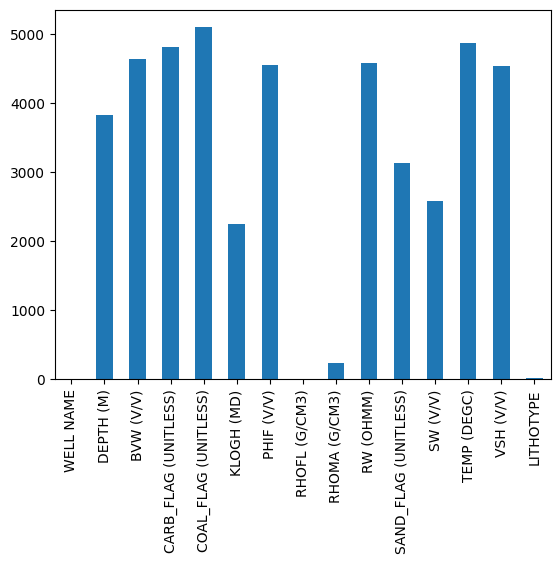

In [ ]:
# Find number of empty/NA values in each column
data.isna().sum().plot(kind="bar")
# Descriptive Statistics
data.describe(include="all").T
# Number of unique values
data.nunique().plot(kind="bar")
# Data Cleaning - How many columns have Null or value=0
data[data == 0].count(axis=0).plot(kind='bar')
data.dropna(inplace=True)
print('Shape of Dataset (rows,columns):', data.shape)

In [ ]:


# separate categorical columns
columns_categ = ['WELL NAME', 'LITHOTYPE']
data_cont = data.drop(data[columns_categ], axis=1)  # continous data
# move response variable to end of dataframe
data_cont = data_cont[[col for col in data_cont.columns if col != 'KLOGH (MD)'] + ['KLOGH (MD)']]
data_cont.info()
# Splitting the dataset
X = data_cont.iloc[:, :-1]
y = data_cont.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

<class 'pandas.core.frame.DataFrame'>
Index: 4818 entries, 0 to 4890
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   DEPTH (M)             4818 non-null   float64
 1   BVW (V/V)             4818 non-null   float64
 2   CARB_FLAG (UNITLESS)  4818 non-null   float64
 3   COAL_FLAG (UNITLESS)  4818 non-null   float64
 4   PHIF (V/V)            4818 non-null   float64
 5   RHOFL (G/CM3)         4818 non-null   float64
 6   RHOMA (G/CM3)         4818 non-null   float64
 7   RW (OHMM)             4818 non-null   float64
 8   SAND_FLAG (UNITLESS)  4818 non-null   float64
 9   SW (V/V)              4818 non-null   float64
 10  TEMP (DEGC)           4818 non-null   float64
 11  VSH (V/V)             4818 non-null   float64
 12  KLOGH (MD)            4818 non-null   float64
dtypes: float64(13)
memory usage: 527.0 KB


In [ ]:
# این دستور توضیحات آماری هر ستون را جداگانه نشان می‌دهد که برای آشنایی بهتر با داده‌ها مناسب است

data.describe()

,DEPTH (M),BVW (V/V),CARB_FLAG (UNITLESS),COAL_FLAG (UNITLESS),KLOGH (MD),PHIF (V/V),RHOFL (G/CM3),RHOMA (G/CM3),RW (OHMM),SAND_FLAG (UNITLESS),SW (V/V),TEMP (DEGC),VSH (V/V)
count,4818.000000,4818.000000,4818.000000,4818.000000,4818.000000,4818.000000,4818.000000,4818.000000,4818.000000,4818.000000,4818.000000,4818.000000,4818.000000
mean,3916.608070,0.100583,0.035127,0.004151,199.005162,0.143943,0.859215,2.657073,0.020866,0.364259,0.762417,117.782825,0.640494
std,139.277452,0.057806,0.183402,0.064302,674.493313,0.063893,0.049149,0.012350,0.000432,0.481269,0.282807,2.901218,0.618236
min,3666.591600,0.000000,0.000000,0.000000,0.000000,0.000000,0.800000,2.630000,0.019953,0.000000,0.042200,112.724900,0.019900
25%,3809.085600,0.063948,0.000000,0.000000,0.000000,0.101849,0.800000,2.650000,0.020576,0.000000,0.560025,115.397200,0.204048
50%,3900.830400,0.091062,0.000000,0.000000,0.002400,0.136374,0.900000,2.660000,0.020894,0.000000,0.886350,117.536150,0.563084
75%,4019.207100,0.118683,0.000000,0.000000,25.815475,0.201043,0.900000,2.660000,0.021220,1.000000,1.000000,119.687475,0.977325
max,4213.860000,0.250109,1.000000,1.000000,11175.424800,0.359646,0.900000,2.710000,0.021643,1.000000,1.000000,124.092100,17.115100


In [ ]:
df.head()

,Unnamed: 0,DEPTH (M),BVW (V/V),CARB_FLAG (UNITLESS),COAL_FLAG (UNITLESS),PHIF (V/V),RHOFL (G/CM3),RHOMA (G/CM3),RW (OHMM),SAND_FLAG (UNITLESS),SW (V/V),TEMP (DEGC),VSH (V/V),KLOGH (MD)
0,0,3666.5916,0.111705,0.0,0.0,0.199843,0.8,2.66,0.021643,0.0,0.5590,112.7249,0.598800,0.0003
1,1,3666.7440,0.112236,0.0,0.0,0.218743,0.8,2.66,0.021642,0.0,0.5131,112.7285,0.599555,0.0000
2,2,3666.8964,0.114825,0.0,0.0,0.242380,0.8,2.66,0.021642,0.0,0.4737,112.7321,0.600310,0.0000
3,3,3667.0488,0.114419,0.0,0.0,0.226408,0.8,2.66,0.021641,0.0,0.5054,112.7358,0.601065,0.0000
4,4,3667.2012,0.115867,0.0,0.0,0.216169,0.8,2.66,0.021640,0.0,0.5360,112.7394,0.601820,0.0000


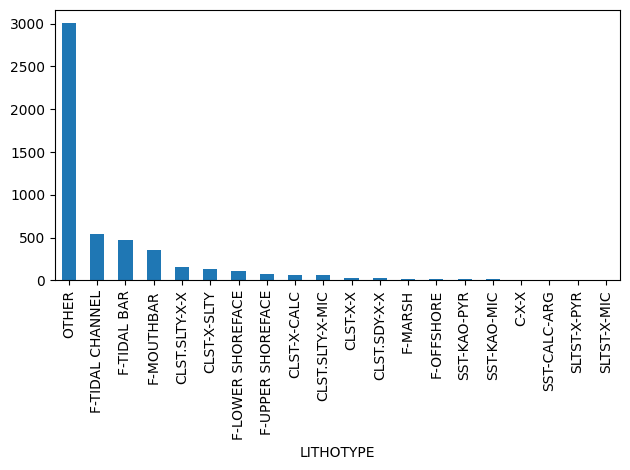

LITHOTYPE
OTHER                3010
F-TIDAL CHANNEL       537
F-TIDAL BAR           476
F-MOUTHBAR            349
CLST.SLTY-X-X         156
CLST-X-SLTY           138
F-LOWER SHOREFACE     105
F-UPPER SHOREFACE      76
CLST-X-CALC            66
CLST.SLTY-X-MIC        59
CLST-X-X               31
CLST.SDY-X-X           29
F-MARSH                20
F-OFFSHORE             20
SST-KAO-PYR            19
SST-KAO-MIC            19
C-X-X                   9
SST-CALC-ARG            4
SLTST-X-PYR             2
SLTST-X-MIC             2
Name: count, dtype: int64


In [6]:
# The response variable in the classification is 'Lithotype' with all remaining features as input'
data['LITHOTYPE'].value_counts().plot(kind='bar')
plt.tight_layout()
plt.savefig('Fig7a.jpg', dpi=600, bbox_inches='tight')
plt.show()
count_categ = data['LITHOTYPE'].value_counts()
print(count_categ)


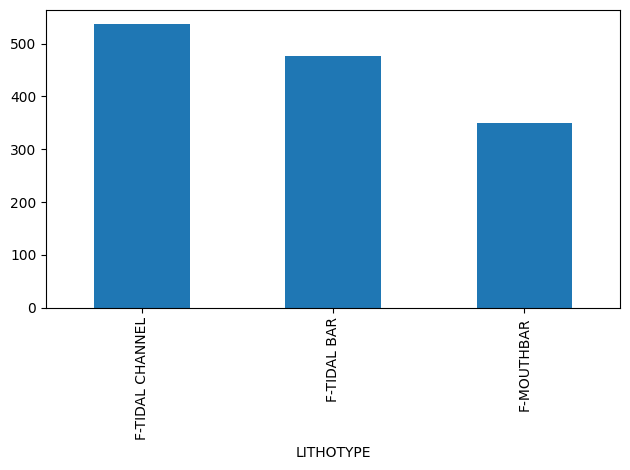

In [9]:
# As observed multiple categories are present, however 'other' won't be considered and
# only the categories with frequency of more than 200 will be included, i.e. 3 categories


data_categ = data[data['LITHOTYPE'].isin(count_categ[count_categ > 200].index)]
data_categ = data_categ[data_categ['LITHOTYPE'] != 'OTHER']
data_categ['LITHOTYPE'].value_counts()
data_categ['LITHOTYPE'].value_counts().plot(kind='bar')
plt.tight_layout()
plt.savefig('Fig7b.jpg', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
data_categ.drop('WELL NAME', axis=1, inplace=True)
data_categ.info()
data_categ.head(10)

<class 'pandas.core.frame.DataFrame'>
Index: 1362 entries, 1018 to 4658
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   DEPTH (M)             1362 non-null   float64
 1   BVW (V/V)             1362 non-null   float64
 2   CARB_FLAG (UNITLESS)  1362 non-null   float64
 3   COAL_FLAG (UNITLESS)  1362 non-null   float64
 4   KLOGH (MD)            1362 non-null   float64
 5   PHIF (V/V)            1362 non-null   float64
 6   RHOFL (G/CM3)         1362 non-null   float64
 7   RHOMA (G/CM3)         1362 non-null   float64
 8   RW (OHMM)             1362 non-null   float64
 9   SAND_FLAG (UNITLESS)  1362 non-null   float64
 10  SW (V/V)              1362 non-null   float64
 11  TEMP (DEGC)           1362 non-null   float64
 12  VSH (V/V)             1362 non-null   float64
 13  LITHOTYPE             1362 non-null   object 
dtypes: float64(13), object(1)
memory usage: 159.6+ KB


,DEPTH (M),BVW (V/V),CARB_FLAG (UNITLESS),COAL_FLAG (UNITLESS),KLOGH (MD),PHIF (V/V),RHOFL (G/CM3),RHOMA (G/CM3),RW (OHMM),SAND_FLAG (UNITLESS),SW (V/V),TEMP (DEGC),VSH (V/V),LITHOTYPE
1018,3821.7348,0.064240,0.0,0.0,121.2722,0.170985,0.8,2.66,0.021074,1.0,0.3763,116.3481,0.142680,F-TIDAL BAR
1019,3821.8872,0.050139,1.0,0.0,0.1000,0.116010,0.8,2.71,0.021073,0.0,0.4359,116.3517,0.118126,F-TIDAL BAR
1020,3822.0396,0.045060,1.0,0.0,0.1000,0.116750,0.8,2.71,0.021073,0.0,0.3905,116.3552,0.130728,F-TIDAL BAR
1021,3822.1920,0.042816,1.0,0.0,0.1000,0.112582,0.8,2.71,0.021072,0.0,0.3831,116.3588,0.110466,F-TIDAL BAR
1022,3822.3444,0.042323,1.0,0.0,0.1000,0.104743,0.8,2.71,0.021072,0.0,0.4099,116.3624,0.126680,F-TIDAL BAR
1023,3822.4968,0.042507,1.0,0.0,0.1000,0.097411,0.8,2.71,0.021071,0.0,0.4409,116.3659,0.105437,F-TIDAL BAR
1024,3822.6492,0.048300,1.0,0.0,0.1000,0.136495,0.8,2.71,0.021071,1.0,0.3560,116.3695,0.128903,F-TIDAL BAR
1025,3822.8016,0.050160,0.0,0.0,43.9027,0.138075,0.8,2.66,0.021070,1.0,0.3684,116.3730,0.162456,F-TIDAL BAR
1026,3822.9540,0.052737,0.0,0.0,84.1097,0.164948,0.8,2.66,0.021070,1.0,0.3215,116.3766,0.154971,F-TIDAL BAR
1027,3823.1064,0.049005,0.0,0.0,79.3844,0.145775,0.8,2.66,0.021069,1.0,0.3384,116.3801,0.140718,F-TIDAL BAR


In [ ]:
X = data_categ.iloc[:, :-1]
y = data_categ.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [ ]:
print('Shape of Training X:', X_train.shape)
print('Shape of Training y:', y_train.shape)
print('Shape of Test X:', X_test.shape)
print('Shape of Test y:', y_test.shape)

Shape of Training X: (1021, 13)
Shape of Training y: (1021,)
Shape of Test X: (341, 13)
Shape of Test y: (341,)


In [ ]:
# defining function for classification metrics
def clf_metrics(test, pred):
    '''Function returns basic metrics for classification models'''
    print('Classification Accuracy Score:', accuracy_score(test, pred))
    print('Confusion Matrix: \n', confusion_matrix(test, pred))
    print('Classification Report: \n', classification_report(test, pred))

In [ ]:
# 1. Logistic Regression
clf_logreg = LogisticRegression()
clf_logreg.fit(X_train, y_train)
# Prediction on test data
y_pred_logreg = clf_logreg.predict(X_test)
# Accuracy Metrics
clf_metrics(y_test, y_pred_logreg)

Classification Accuracy Score: 0.6480938416422287
Confusion Matrix: 
 [[  4  70  13]
 [  5 102  12]
 [  1  19 115]]
Classification Report: 
                  precision    recall  f1-score   support

     F-MOUTHBAR       0.40      0.05      0.08        87
    F-TIDAL BAR       0.53      0.86      0.66       119
F-TIDAL CHANNEL       0.82      0.85      0.84       135

       accuracy                           0.65       341
      macro avg       0.59      0.58      0.53       341
   weighted avg       0.61      0.65      0.58       341



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
